# Resumo do Notebook

Neste notebook, fazemos a leitura da base de dados tratada da Locaweb que foi armazenada na nuvem após a execução do [ETL.py](../ETL.py), fazemos novamente mais uma exploração nos dados para identificar o período dos incidentes, realizar dois cortes nos dados para fornecer dados mais atualizados para um modelo preditivo. Durante a execução dos cortes, pensamos se tinha algum valor nos dados que foram cortados e que violaram o KPI e descobrimos um Insight Interessante. Após isso, seguimos com uma seção robusta de Engenharia de Features para preparar os DataFrames para criar os modelos preditivos para previsão D+1 e D+7. Logo em seguida, treinamos os modelos XGBoost para D+1 e D+7, avaliamos e investigamos as categorias que mais assombram os times de suporte da Locaweb, além de verificar o impacto de feriados no volume de incidentes. Após isso, partimos para a classificação de OLA utilizando K-means  separaramos os incidentes em 04 clusters utilizando o método do cotôvelo e, por fim, testamos a inserção das tabelas resultantes na nuvem. Este notebook também serviu como base para o [02_motor_preditivo.py](..\Pipeline_Producao\02_motor_preditivo.py).

In [149]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import oracledb
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from sqlalchemy.dialects.oracle import NUMBER, TIMESTAMP, VARCHAR2

load_dotenv()
warnings.filterwarnings('ignore')

In [150]:
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
CONNECT_STRING = '(description= (retry_count=20)(retry_delay=3)(address=(protocol=tcps)(port=1522)(host=adb.sa-saopaulo-1.oraclecloud.com))(connect_data=(service_name=g253a13c6f2211a_dadosaiopslocaweb_low.adb.oraclecloud.com))(security=(ssl_server_dn_match=yes)))'

def conectar_oracle():
    return oracledb.connect(
        user=DB_USER,
        password=DB_PASSWORD,
        dsn=CONNECT_STRING,
        wallet_location=r"C:/opt/OracleCloud/Wallet_dadosAIOpsLocaweb",
        wallet_password=DB_PASSWORD
    )

In [151]:
# Ler dados de uma view do banco de dados oracle
df = pd.read_sql_query("SELECT * FROM admin.TB_INCIDENTES_LOCAWEB", con=conectar_oracle()) # pyright: ignore[reportArgumentType]

In [152]:
df.shape

(122543, 19)

In [153]:
df.sample(50)

,CD_INCIDENTE,TP_PRIORIDADE,NM_PRODUTO,NM_CATEGORIA,NM_SUBCATEGORIA,NM_GRUPO_DESIGNADO,NM_ITEM_CONFIGURACAO,DT_ABERTO,DT_RESOLVIDO,DT_ENCERRADO,NR_DURACAO,CD_FECHAMENTO,DS_RESUMIDA,TP_SOLUCAO,TP_ABERTO_POR,CD_INCIDENTE_PAI,TP_STATUS,FL_KPI,FL_KPI_VIOLADO
44650,INC8595482,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00004,2025-11-09 02:28:02,NaT,2025-11-09 02:28:54,52,Em andamento,Problem: Alarm Application Monitoring feeds Me...,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
120009,INC8279618,4 - Baixa,lhco,cat71,sub427,Team09,IC00896,2025-01-28 15:28:31,NaT,2025-04-04 11:22:56,5687665,Falha de Hardware,[MONITORAÇÃO] Configuração de Usuário e Senha ...,Nenhuma,Manual,NaN,Encerrado,NAO,NAO
98684,INC8491927,3 - Média,lemn,cat45,sub30,Team05,IC00341,2025-08-08 09:06:41,2025-12-14 11:29:17,2025-12-19 01:01:22,11067756,Falha de Segurança,Problem: Check PMTA IC00622 Queue,Contorno,Monitoramento,INC8491921,Encerrado Automaticamente,NAO,SIM
82038,INC8540969,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00019,2025-09-20 21:46:51,NaT,2025-09-20 21:47:31,40,Em andamento,Problem: Check Application Monitoring,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
2354,INC8651154,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00143,2025-12-29 04:05:28,NaT,2025-12-29 04:07:47,139,Em andamento,Problem: Disk I/O is overloaded on IC00143,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
20018,INC8631740,2 - Alta,Nao Informado,Nao Informado,Nao Informado,Team14,IC01330,2025-12-13 12:14:56,2025-12-13 14:14:53,2025-12-13 14:17:29,7197,Falha de Hardware,Problem: Unavailable by ICMP ping,Nenhuma,Monitoramento,INC8631733,Encerrado,NAO,NAO
32624,INC8614221,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00002,2025-11-27 13:18:03,NaT,2025-11-27 13:18:40,37,Em andamento,Problem: Check Application Monitoring,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
90495,INC8527348,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00019,2025-09-05 15:17:02,NaT,2025-09-05 15:17:34,32,Em andamento,Problem: Check Application Monitoring VIP,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
14943,INC8637090,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00325,2025-12-17 20:11:59,NaT,2025-12-17 20:17:04,305,Em andamento,Problem: IC06745 - IC01442 - Servidores com er...,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
54344,INC8574663,3 - Média,lcem,cat76,sub285,Team05,IC04157,2025-10-20 22:35:18,2025-10-20 22:42:56,2025-10-25 01:01:52,458,Falha de Aplicação,Problem: Free disk space is less than 5% on vo...,Nenhuma,Monitoramento,INC8574662,Encerrado Automaticamente,NAO,NAO


In [154]:
print(df['DT_ABERTO'].min())
print("\n",df['DT_ABERTO'].max())


2023-01-02 20:19:58

 2025-12-31 23:45:18


In [155]:
df.columns

Index(['CD_INCIDENTE', 'TP_PRIORIDADE', 'NM_PRODUTO', 'NM_CATEGORIA',
       'NM_SUBCATEGORIA', 'NM_GRUPO_DESIGNADO', 'NM_ITEM_CONFIGURACAO',
       'DT_ABERTO', 'DT_RESOLVIDO', 'DT_ENCERRADO', 'NR_DURACAO',
       'CD_FECHAMENTO', 'DS_RESUMIDA', 'TP_SOLUCAO', 'TP_ABERTO_POR',
       'CD_INCIDENTE_PAI', 'TP_STATUS', 'FL_KPI', 'FL_KPI_VIOLADO'],
      dtype='str')

In [156]:
df.isna().sum()

CD_INCIDENTE                 0
TP_PRIORIDADE                0
NM_PRODUTO                   0
NM_CATEGORIA                 0
NM_SUBCATEGORIA              0
NM_GRUPO_DESIGNADO           0
NM_ITEM_CONFIGURACAO         0
DT_ABERTO                    0
DT_RESOLVIDO             82302
DT_ENCERRADO                 0
NR_DURACAO                   0
CD_FECHAMENTO                0
DS_RESUMIDA                  0
TP_SOLUCAO                   0
TP_ABERTO_POR                0
CD_INCIDENTE_PAI        107416
TP_STATUS                    0
FL_KPI                       0
FL_KPI_VIOLADO               0
dtype: int64

In [157]:
df['TP_PRIORIDADE'].value_counts()

TP_PRIORIDADE
4 - Baixa          64828
3 - Média          41732
2 - Alta           15649
5 - Muito Baixa      333
1 - Crítica            1
Name: count, dtype: int64

In [158]:
df.dtypes

CD_INCIDENTE                       str
TP_PRIORIDADE                      str
NM_PRODUTO                         str
NM_CATEGORIA                       str
NM_SUBCATEGORIA                    str
NM_GRUPO_DESIGNADO                 str
NM_ITEM_CONFIGURACAO               str
DT_ABERTO               datetime64[us]
DT_RESOLVIDO            datetime64[us]
DT_ENCERRADO            datetime64[us]
NR_DURACAO                       int64
CD_FECHAMENTO                      str
DS_RESUMIDA                        str
TP_SOLUCAO                         str
TP_ABERTO_POR                      str
CD_INCIDENTE_PAI                   str
TP_STATUS                          str
FL_KPI                             str
FL_KPI_VIOLADO                     str
dtype: object

In [159]:
df['DT_ABERTO'] = pd.to_datetime(df['DT_ABERTO'])
df['DT_ENCERRADO'] = pd.to_datetime(df['DT_ENCERRADO'])
df['DT_RESOLVIDO'] = pd.to_datetime(df['DT_RESOLVIDO'])

In [160]:
incidentes_dia = df.groupby(df['DT_ABERTO'].dt.date)['TP_PRIORIDADE'].count()

In [161]:
incidentes_dia

DT_ABERTO
2023-01-02       1
2023-01-09       1
2023-01-11       2
2023-01-16       1
2023-01-17       2
              ... 
2025-12-27    1027
2025-12-28     829
2025-12-29     921
2025-12-30     866
2025-12-31     755
Name: TP_PRIORIDADE, Length: 644, dtype: int64

In [162]:
print(f"A quantidade de dias no dataset é de: {df['DT_ABERTO'].dt.date.max() - df['DT_ABERTO'].dt.date.min()}, \
      \ndata inicial: {df['DT_ABERTO'].dt.date.min()} \
      \ndata final: {df['DT_ABERTO'].dt.date.max()}")

A quantidade de dias no dataset é de: 1094 days, 0:00:00,       
data inicial: 2023-01-02       
data final: 2025-12-31


## Nem todas as datas estão preenchidas

<Axes: xlabel='DT_ABERTO'>

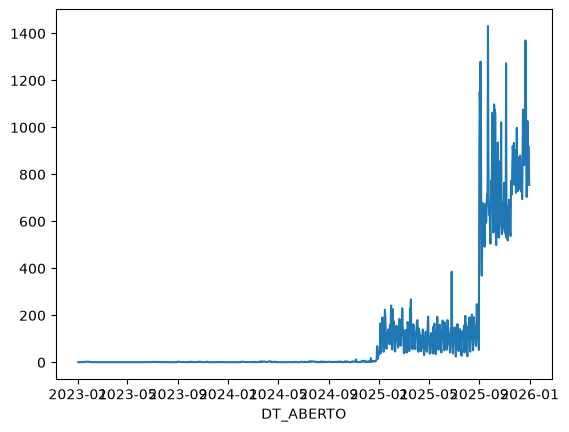

In [163]:
incidentes_dia.plot(legend=False)

## Muito ruído até 2025 

In [164]:
data_limite = pd.to_datetime('2024-12-31')

In [165]:
incidentes_dia = incidentes_dia.reset_index()

In [166]:
incidentes_dia.columns

Index(['DT_ABERTO', 'TP_PRIORIDADE'], dtype='str')

In [167]:
incidentes_dia['DT_ABERTO'] = pd.to_datetime(incidentes_dia['DT_ABERTO']) 

In [168]:
df_filtrado = incidentes_dia[incidentes_dia['DT_ABERTO'] > data_limite]
df_filtrado

,DT_ABERTO,TP_PRIORIDADE
279,2025-01-01,34
280,2025-01-02,55
281,2025-01-03,77
282,2025-01-04,166
283,2025-01-05,39
...,...,...
639,2025-12-27,1027
640,2025-12-28,829
641,2025-12-29,921
642,2025-12-30,866


<Axes: xlabel='DT_ABERTO'>

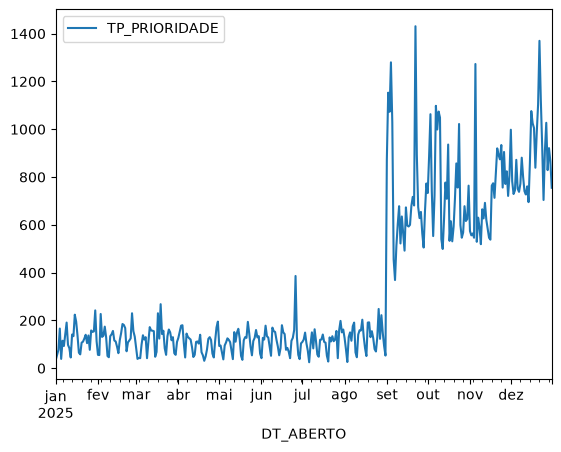

In [169]:
df_filtrado.plot(x ='DT_ABERTO',y='TP_PRIORIDADE')

# Será que os valores de 2023-2024 não tem valor algum? Verificar os que violaram KPI, se existir.

In [170]:
df.head()

,CD_INCIDENTE,TP_PRIORIDADE,NM_PRODUTO,NM_CATEGORIA,NM_SUBCATEGORIA,NM_GRUPO_DESIGNADO,NM_ITEM_CONFIGURACAO,DT_ABERTO,DT_RESOLVIDO,DT_ENCERRADO,NR_DURACAO,CD_FECHAMENTO,DS_RESUMIDA,TP_SOLUCAO,TP_ABERTO_POR,CD_INCIDENTE_PAI,TP_STATUS,FL_KPI,FL_KPI_VIOLADO
0,INC8654070,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00016,2025-12-31 17:43:19,NaT,2025-12-31 17:45:56,157,Em andamento,Problem: Disk I/O is overloaded on IC00016,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
1,INC8654069,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00028,2025-12-31 17:42:06,NaT,2025-12-31 17:51:52,586,Em andamento,Problem: Disk I/O is overloaded on IC00028,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
2,INC8654068,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00006,2025-12-31 17:42:03,NaT,2025-12-31 17:47:08,305,Em andamento,Problem: Disk I/O is overloaded on IC00006,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
3,INC8654067,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00014,2025-12-31 17:40:23,NaT,2025-12-31 18:10:06,1783,Em andamento,Problem: Check Application Monitoring,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
4,INC8654066,4 - Baixa,Nao Informado,Nao Informado,Nao Informado,Team14,IC00012,2025-12-31 17:39:16,NaT,2025-12-31 18:05:12,1556,Em andamento,Problem: Check Application Monitoring,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO


In [171]:
df['FL_KPI_VIOLADO'].value_counts()

FL_KPI_VIOLADO
NAO    118035
SIM      4508
Name: count, dtype: int64

In [172]:
cond1 = df['DT_ABERTO'] < data_limite
cond2 = df['FL_KPI_VIOLADO'] == 'SIM'

df_filtrado2 = df[cond1 & cond2]

In [173]:
df_filtrado2

,CD_INCIDENTE,TP_PRIORIDADE,NM_PRODUTO,NM_CATEGORIA,NM_SUBCATEGORIA,NM_GRUPO_DESIGNADO,NM_ITEM_CONFIGURACAO,DT_ABERTO,DT_RESOLVIDO,DT_ENCERRADO,NR_DURACAO,CD_FECHAMENTO,DS_RESUMIDA,TP_SOLUCAO,TP_ABERTO_POR,CD_INCIDENTE_PAI,TP_STATUS,FL_KPI,FL_KPI_VIOLADO
120913,INC8129383,3 - Média,lcem,cat76,sub438,Team05,IC05113,2024-09-26 04:51:46,2025-02-15 00:53:42,2025-02-20 01:00:13,12254516,Falso Positivo,Problem: Check Local Autentication on IC05113,Nenhuma,Monitoramento,NaN,Encerrado Automaticamente,SIM,SIM
120914,INC8129017,3 - Média,lcem,cat76,sub438,Team05,IC02093,2024-09-25 21:39:48,2025-02-15 00:51:55,2025-02-20 01:00:13,12280327,Falso Positivo,Problem: Check Local Autentication on IC02093,Nenhuma,Monitoramento,NaN,Encerrado Automaticamente,SIM,SIM
120915,INC8128990,3 - Média,lcem,cat76,sub438,Team05,IC03167,2024-09-25 21:06:53,2025-02-15 00:51:52,2025-02-20 01:00:12,12282299,Falso Positivo,Problem: Check Local Autentication on IC03167,Nenhuma,Monitoramento,NaN,Encerrado Automaticamente,SIM,SIM
120916,INC8128846,3 - Média,lcem,cat76,sub438,Team05,IC07467,2024-09-25 19:28:49,2025-09-02 15:55:59,2025-09-07 01:00:18,29536030,Falha de Aplicação,Aviso de férias,Definitiva,Manual,NaN,Encerrado Automaticamente,SIM,SIM
120917,INC8128206,3 - Média,lcem,cat91,sub65,Team11,IC00604,2024-09-25 08:22:33,2025-07-08 08:26:23,2025-07-10 14:05:40,24710630,Falha de Aplicação,[Falha na inclusão do adicional] - distribuido...,Nenhuma,Manual,NaN,Encerrado,SIM,SIM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122534,INC8136560,3 - Média,lcem,cat91,sub12,Team11,IC00604,2024-10-01 16:11:08,2025-07-08 08:56:22,2025-07-13 01:00:13,24165914,Em andamento,Falha no painel | vectorcontainersIC04172com,Nenhuma,Manual,NaN,Encerrado Automaticamente,SIM,SIM
122535,INC8136409,3 - Média,lcsi,cat41,sub152,Team14,IC00725,2024-10-01 13:19:06,2025-11-25 15:40:08,2025-11-30 01:00:31,36296462,Falha de Aplicação,Falha na publicação de site - ttconsultoriaspe...,Definitiva,Manual,NaN,Encerrado Automaticamente,SIM,SIM
122536,INC8135010,3 - Média,lhco,cat85,sub206,Team11,IC07218,2024-09-30 17:12:43,2025-07-08 08:55:34,2025-07-13 01:00:12,24248571,Falha de Aplicação,Inside Sales | Normandia | Falha na Ativação –...,Nenhuma,Manual,NaN,Encerrado Automaticamente,SIM,SIM
122541,INC8132164,3 - Média,lcem,cat91,sub12,Team05,IC00604,2024-09-28 11:41:15,2025-02-18 09:23:49,2025-02-23 01:00:13,12346954,Falha de Aplicação,Falha ao excluir apelido no painel de e-mail,Nenhuma,Manual,NaN,Encerrado Automaticamente,SIM,SIM


## Insight Operacional 

Durante a Análise Exploratória (EDA), identificamos incidentes que demoraram até 340 dias para serem encerrados, sendo alguns classificados apenas como "Falsos Positivos". Esses "tickets órfãos" geram violações de OLA administrativas que mancham o indicador anual da equipe sem que haja um problema técnico real ocorrendo. Uma sugestão seria configurar na ferramenta de ITSM (ServiceNow, Jira, etc.) uma automação de "Timeout de Fila". Se um chamado P2/P3 ficar sem interação por mais de 48 horas, a ferramenta deve disparar um alerta para o Coordenador da equipe ou mudar o status para "Aguardando Usuário", congelando o relógio do OLA.

# Mais um Data Trimming

<Axes: xlabel='DT_ABERTO'>

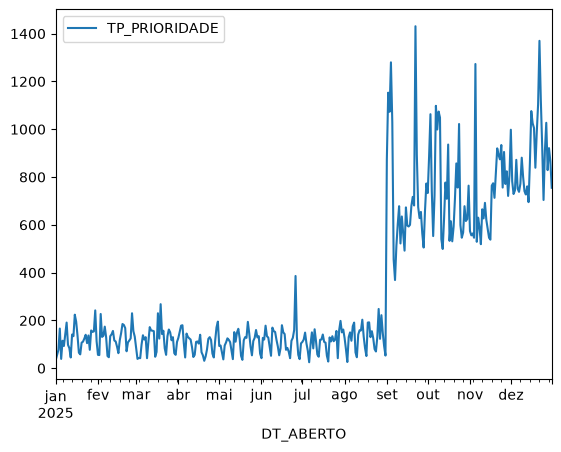

In [174]:
df_filtrado.plot(x ='DT_ABERTO',y='TP_PRIORIDADE')

## Há uma diferença muito grande entre o volume de incidentes de Jan-Ago/2025 e Set-Dez/2025, justificando mais um Data Trimming para criar um modelo que possa predizer de forma precisa os incidentes atuais. No entanto, já podemos alertar de que caso ocorram mais mudanças muito bruscas como essas, pode ser necessário descartar os dados antigos e considerar novamente os mais recentes, identificando os marcos de tempo. 

In [175]:
data_limite = '2025-08-31'

In [176]:
df_filtrado = df_filtrado[df_filtrado['DT_ABERTO'] > data_limite]

In [177]:
df_filtrado.shape

(122, 2)

In [178]:
df_filtrado.head()

,DT_ABERTO,TP_PRIORIDADE
522,2025-09-01,874
523,2025-09-02,1153
524,2025-09-03,1073
525,2025-09-04,1280
526,2025-09-05,1030


# Feature Engineering

## Features de Calendário (Sazonalidade)
Estas variáveis ajudam a árvore de decisão a entender o contexto temporal (válidas tanto para D+1 quanto para D+7)

In [179]:
df_filtrado['dia_semana'] = df_filtrado['DT_ABERTO'].dt.day_of_week

In [180]:
def fim_semana(dia):
    if dia < 5:
        return 0
    else:
        return 1
    
df_filtrado['fl_fim_semana'] = df_filtrado['dia_semana'].apply(fim_semana)

In [181]:
df_filtrado['dia_mes'] = df_filtrado['DT_ABERTO'].dt.day

In [182]:
df_filtrado['mes'] = df_filtrado['DT_ABERTO'].dt.month

In [183]:
df_filtrado.head(10)

,DT_ABERTO,TP_PRIORIDADE,dia_semana,fl_fim_semana,dia_mes,mes
522,2025-09-01,874,0,0,1,9
523,2025-09-02,1153,1,0,2,9
524,2025-09-03,1073,2,0,3,9
525,2025-09-04,1280,3,0,4,9
526,2025-09-05,1030,4,0,5,9
527,2025-09-06,455,5,1,6,9
528,2025-09-07,369,6,1,7,9
529,2025-09-08,511,0,0,8,9
530,2025-09-09,602,1,0,9,9
531,2025-09-10,678,2,0,10,9


## Features para D+1 (Inércia de Curto Prazo)
Para prever amanhã, o modelo pode e deve olhar para o que aconteceu hoje e ontem.

In [184]:
colunas = { 
           'DT_ABERTO' : 'data',
           'TP_PRIORIDADE': 'vol_total'}

df_filtrado = df_filtrado.rename(columns= colunas)

In [185]:
# Volume total de incidentes do dia anterior.
df_filtrado['vol_total_lag_1'] = df_filtrado['vol_total'].shift(1)

In [186]:
# Volume de 2 e 3 dias atrás (captura a aceleração ou desaceleração do caos).
df_filtrado['vol_total_lag_2'] = df_filtrado['vol_total'].shift(2)
df_filtrado['vol_total_lag_3'] = df_filtrado['vol_total'].shift(3)

In [187]:
# A média de volume dos últimos 3 e 7 dias. Suaviza os picos e mostra a tendência real para a árvore.
df_filtrado['media_movel_3d'] = df_filtrado['vol_total'].rolling(window=3, min_periods=1).mean()
df_filtrado['media_movel_7d'] = df_filtrado['vol_total'].rolling(window=7, min_periods=1).mean()

In [188]:
df_filtrado.head()

,data,vol_total,dia_semana,fl_fim_semana,dia_mes,mes,vol_total_lag_1,vol_total_lag_2,vol_total_lag_3,media_movel_3d,media_movel_7d
522,2025-09-01,874,0,0,1,9,NaN,NaN,NaN,874.000000,874.000000
523,2025-09-02,1153,1,0,2,9,874.0,NaN,NaN,1013.500000,1013.500000
524,2025-09-03,1073,2,0,3,9,1153.0,874.0,NaN,1033.333333,1033.333333
525,2025-09-04,1280,3,0,4,9,1073.0,1153.0,874.0,1168.666667,1095.000000
526,2025-09-05,1030,4,0,5,9,1280.0,1073.0,1153.0,1127.666667,1082.000000


# Features para D+7
Se hoje é segunda-feira e você quer prever a próxima segunda-feira, você não pode usar dados de amanhã até domingo. O modelo só pode olhar do dia de hoje para trás.

In [189]:
# O que aconteceu neste mesmo dia da semana, na semana passada.
df_filtrado['vol_total_lag_7'] = df_filtrado['vol_total'].shift(7)

In [190]:
# Volume de exatas duas semanas atrás
df_filtrado['vol_total_lag_14'] = df_filtrado['vol_total'].shift(14)

In [191]:
# A média móvel da semana, mas calculada com um atraso de 7 dias (para garantir que o modelo não espie o futuro).
df_filtrado['media_movel_7d_deslocada'] = df_filtrado['vol_total'].shift(7).rolling(window=7, min_periods=1).mean()

## Features de Pressão Operacional
Transformaremos linhas individuais em contagens diárias defasadas.

## Adicionando a contagem das prioridades do incidente para cada data 

In [192]:
df.TP_PRIORIDADE.value_counts()

TP_PRIORIDADE
4 - Baixa          64828
3 - Média          41732
2 - Alta           15649
5 - Muito Baixa      333
1 - Crítica            1
Name: count, dtype: int64

In [193]:
df['DATA'] = df['DT_ABERTO'].dt.date

In [194]:
prioridade_dia = df.groupby(['DATA', 'TP_PRIORIDADE']).size().reset_index(name='contagem')

In [195]:
prioridade_dia

,DATA,TP_PRIORIDADE,contagem
0,2023-01-02,3 - Média,1
1,2023-01-09,3 - Média,1
2,2023-01-11,3 - Média,2
3,2023-01-16,3 - Média,1
4,2023-01-17,3 - Média,2
...,...,...,...
1586,2025-12-30,3 - Média,468
1587,2025-12-30,4 - Baixa,369
1588,2025-12-31,2 - Alta,15
1589,2025-12-31,3 - Média,372


In [196]:
prioridades = {
    '1 - Crítica': 1,
    '2 - Alta': 2,
    '3 - Média': 3,
    '4 - Baixa': 4,
    '5 - Muito Baixa': 5
}

def converter_prioridades(df, coluna='TP_PRIORIDADE'):
    df[coluna] = df[coluna].map(prioridades)
    return df

converter_prioridades(prioridade_dia)

,DATA,TP_PRIORIDADE,contagem
0,2023-01-02,3,1
1,2023-01-09,3,1
2,2023-01-11,3,2
3,2023-01-16,3,1
4,2023-01-17,3,2
...,...,...,...
1586,2025-12-30,3,468
1587,2025-12-30,4,369
1588,2025-12-31,2,15
1589,2025-12-31,3,372


In [197]:
tabela = prioridade_dia.pivot(index='DATA', columns='TP_PRIORIDADE', values='contagem').fillna(0)

In [198]:
tabela.head()

TP_PRIORIDADE,1,2,3,4,5
DATA,,,,,
2023-01-02,0.0,0.0,1.0,0.0,0.0
2023-01-09,0.0,0.0,1.0,0.0,0.0
2023-01-11,0.0,0.0,2.0,0.0,0.0
2023-01-16,0.0,0.0,1.0,0.0,0.0
2023-01-17,0.0,0.0,2.0,0.0,0.0


In [199]:
tabela.reset_index(inplace=True)

In [200]:
tabela.dtypes

TP_PRIORIDADE
DATA     object
1       float64
2       float64
3       float64
4       float64
5       float64
dtype: object

In [201]:
tabela['DATA'] = pd.to_datetime(tabela['DATA'])

In [202]:
tabela = tabela[tabela['DATA'] > data_limite]

In [203]:
tabela.shape

(122, 6)

In [204]:
df_filtrado.shape

(122, 14)

In [205]:
tabela.rename(columns={'DATA':'data'}, inplace=True)

In [206]:
tabela.head()

TP_PRIORIDADE,data,1,2,3,4,5
522,2025-09-01,0.0,39.0,125.0,710.0,0.0
523,2025-09-02,0.0,296.0,171.0,686.0,0.0
524,2025-09-03,0.0,41.0,114.0,918.0,0.0
525,2025-09-04,0.0,187.0,151.0,942.0,0.0
526,2025-09-05,0.0,56.0,149.0,825.0,0.0


In [207]:
df_filtrado.head()

,data,vol_total,dia_semana,fl_fim_semana,dia_mes,mes,vol_total_lag_1,vol_total_lag_2,vol_total_lag_3,media_movel_3d,media_movel_7d,vol_total_lag_7,vol_total_lag_14,media_movel_7d_deslocada
522,2025-09-01,874,0,0,1,9,NaN,NaN,NaN,874.000000,874.000000,NaN,NaN,NaN
523,2025-09-02,1153,1,0,2,9,874.0,NaN,NaN,1013.500000,1013.500000,NaN,NaN,NaN
524,2025-09-03,1073,2,0,3,9,1153.0,874.0,NaN,1033.333333,1033.333333,NaN,NaN,NaN
525,2025-09-04,1280,3,0,4,9,1073.0,1153.0,874.0,1168.666667,1095.000000,NaN,NaN,NaN
526,2025-09-05,1030,4,0,5,9,1280.0,1073.0,1153.0,1127.666667,1082.000000,NaN,NaN,NaN


In [208]:
tabela.set_index('data', inplace=True)

In [209]:
df_final = df_filtrado.merge(tabela, on='data', how='left')

In [210]:
df_final.dtypes

data                        datetime64[s]
vol_total                           int64
dia_semana                          int32
fl_fim_semana                       int64
dia_mes                             int32
mes                                 int32
vol_total_lag_1                   float64
vol_total_lag_2                   float64
vol_total_lag_3                   float64
media_movel_3d                    float64
media_movel_7d                    float64
vol_total_lag_7                   float64
vol_total_lag_14                  float64
media_movel_7d_deslocada          float64
1                                 float64
2                                 float64
3                                 float64
4                                 float64
5                                 float64
dtype: object

In [211]:
prioridades = {
    1 : 'vol_p1',
    2 : 'vol_p2',
    3 : 'vol_p3',
    4 : 'vol_p4',
    5 : 'vol_p5'
}

df_final.rename(columns=prioridades, inplace=True)

### Pressão por Prioridade
Se a equipe de TI foi inundada por chamados de baixa prioridade hoje, o cansaço e o backlog podem estourar o volume crítico amanhã. 

In [212]:
colunas_prioridade = ['vol_p2', 'vol_p3', 'vol_p4', 'vol_p5']
lags = [1, 7]

for col in colunas_prioridade:
    for lag in lags:
        df_final[f'{col}_lag_{lag}'] = df_final[col].shift(lag)

print("Colunas criadas:")
print([col for col in df_final.columns if 'lag' in col])

Colunas criadas:
['vol_total_lag_1', 'vol_total_lag_2', 'vol_total_lag_3', 'vol_total_lag_7', 'vol_total_lag_14', 'vol_p2_lag_1', 'vol_p2_lag_7', 'vol_p3_lag_1', 'vol_p3_lag_7', 'vol_p4_lag_1', 'vol_p4_lag_7', 'vol_p5_lag_1', 'vol_p5_lag_7']


### Carga de Monitoramento
O dicionário aponta que incidentes de monitoramento geram volume sem intervenção humana. Um pico aqui hoje pode indicar uma instabilidade sistêmica silenciosa que vai gerar chamados manuais amanhã.

In [213]:
tabela = df.groupby(['DATA','TP_ABERTO_POR']).size().reset_index(name='contagem')

In [214]:
tabela.rename(columns={'DATA':'data'}, inplace=True)

In [215]:
tabela = tabela.pivot(index='data', columns='TP_ABERTO_POR', values='contagem').fillna(0)

In [216]:
tabela.rename(columns={'Manual':'vol_aberto_manual', 'Monitoramento': 'vol_aberto_monitoramento'}, inplace=True)

In [217]:
tabela.reset_index(inplace=True)

In [218]:
tabela['data'] = pd.to_datetime(tabela['data'])

In [219]:
tabela.dtypes

TP_ABERTO_POR
data                        datetime64[s]
vol_aberto_manual                 float64
vol_aberto_monitoramento          float64
dtype: object

In [220]:
df_final = df_final.merge(tabela, on='data', how='left')

In [221]:
df_final.dtypes

data                        datetime64[s]
vol_total                           int64
dia_semana                          int32
fl_fim_semana                       int64
dia_mes                             int32
mes                                 int32
vol_total_lag_1                   float64
vol_total_lag_2                   float64
vol_total_lag_3                   float64
media_movel_3d                    float64
media_movel_7d                    float64
vol_total_lag_7                   float64
vol_total_lag_14                  float64
media_movel_7d_deslocada          float64
vol_p1                            float64
vol_p2                            float64
vol_p3                            float64
vol_p4                            float64
vol_p5                            float64
vol_p2_lag_1                      float64
vol_p2_lag_7                      float64
vol_p3_lag_1                      float64
vol_p3_lag_7                      float64
vol_p4_lag_1                      

## Focos de Incêndio (Top 7)
Escolhemos as 7 equipes mais requisitadas (nm_grupo_designado) e as 5 categorias (nm_categoria) que mais recebem chamados no geral. Criamos features diárias do tipo vol_team14_lag e vol_cat_banco_de_dados_lag. Isso ensinará ao modelo onde o problema costuma nascer antes de se espalhar.

### Top 7 equipes mais requisitadas

In [222]:
equipes = df[df['DT_ABERTO'] > data_limite].groupby('NM_GRUPO_DESIGNADO')['DATA'].count().sort_values(ascending=False)
equipes.head(17)

NM_GRUPO_DESIGNADO
Team14    81760
Team05     3912
Team11     2400
Team12     1494
Team09     1154
Team10     1044
Team03      761
Team02      264
Team17      243
Team01      116
Team16      113
Team07       86
Team04       77
Team08       28
Team15       20
Team06        3
Team13        1
Name: DATA, dtype: int64

### Top 6 Categorias mais frequentes

In [223]:
categoria = df[df['DT_ABERTO'] > data_limite].groupby('NM_CATEGORIA')['DATA'].count().sort_values(ascending=False)
categoria.head(114)

NM_CATEGORIA
Nao Informado    76739
cat71             3293
cat77             2344
cat76             1524
cat73             1297
                 ...  
cat69                1
cat79                1
cat80                1
cat9                 1
cat86                1
Name: DATA, Length: 114, dtype: int64

In [224]:
df_final.head()

,data,vol_total,dia_semana,fl_fim_semana,dia_mes,mes,vol_total_lag_1,vol_total_lag_2,vol_total_lag_3,media_movel_3d,...,vol_p2_lag_1,vol_p2_lag_7,vol_p3_lag_1,vol_p3_lag_7,vol_p4_lag_1,vol_p4_lag_7,vol_p5_lag_1,vol_p5_lag_7,vol_aberto_manual,vol_aberto_monitoramento
0,2025-09-01,874,0,0,1,9,NaN,NaN,NaN,874.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.0,829.0
1,2025-09-02,1153,1,0,2,9,874.0,NaN,NaN,1013.500000,...,39.0,NaN,125.0,NaN,710.0,NaN,0.0,NaN,62.0,1091.0
2,2025-09-03,1073,2,0,3,9,1153.0,874.0,NaN,1033.333333,...,296.0,NaN,171.0,NaN,686.0,NaN,0.0,NaN,55.0,1018.0
3,2025-09-04,1280,3,0,4,9,1073.0,1153.0,874.0,1168.666667,...,41.0,NaN,114.0,NaN,918.0,NaN,0.0,NaN,54.0,1226.0
4,2025-09-05,1030,4,0,5,9,1280.0,1073.0,1153.0,1127.666667,...,187.0,NaN,151.0,NaN,942.0,NaN,0.0,NaN,51.0,979.0


In [225]:
df_final.set_index('data', inplace=True)

In [226]:
# 1. Definindo suas listas de interesse
categorias_alvo = ['Nao Informado', 'cat71', 'cat77', 'cat76', 'cat73', 'cat85']
times_alvo = ['Team14', 'Team05', 'Team11', 'Team12', 'Team09', 'Team10', 'Team03']

# 2. Garantindo que o 'df' bruto tenha uma coluna apenas com a data (sem as horas)
df['DATA'] = pd.to_datetime(df['DT_ABERTO']).dt.floor('D')

# 3. Criando as matrizes de contagem diária
# Conta quantas vezes cada categoria e cada time apareceu por dia
cat_counts = pd.crosstab(df['DATA'], df['NM_CATEGORIA'])
team_counts = pd.crosstab(df['DATA'], df['NM_GRUPO_DESIGNADO'])

# Filtra apenas as colunas que estão nas suas listas (evita erros se uma categoria não existir)
colunas_cat_reais = [c for c in categorias_alvo if c in cat_counts.columns]
colunas_team_reais = [t for t in times_alvo if t in team_counts.columns]

cat_counts = cat_counts[colunas_cat_reais]
team_counts = team_counts[colunas_team_reais]

# 4. Juntando as contagens no seu df_final
df_final = df_final.join(cat_counts, how='left').fillna(0)
df_final = df_final.join(team_counts, how='left').fillna(0)

# 5. Criando os Lags 
todas_novas_colunas = colunas_cat_reais + colunas_team_reais
lags = [1, 7]

for col in todas_novas_colunas:
    # Renomeando e criando o lag para manter o padrão 'vol_nome_lag_x'
    nome_limpo = col.replace(' ', '_').lower() # Ex: 'Não Informado' vira 'não_informado'
    
    for lag in lags:
        df_final[f'vol_{nome_limpo}_lag_{lag}'] = df_final[col].shift(lag)
        
    # O modelo D+1/D+7 só pode ver os dados de "ontem" e da "semana passada"
    df_final.drop(columns=[col], inplace=True)

# Remove os dias iniciais que ficaram com NaN devido ao lag_7
df_final.dropna(inplace=True)

print("Colunas de contexto criadas com sucesso:")
print([c for c in df_final.columns if 'lag' in c])

Colunas de contexto criadas com sucesso:
['vol_total_lag_1', 'vol_total_lag_2', 'vol_total_lag_3', 'vol_total_lag_7', 'vol_total_lag_14', 'vol_p2_lag_1', 'vol_p2_lag_7', 'vol_p3_lag_1', 'vol_p3_lag_7', 'vol_p4_lag_1', 'vol_p4_lag_7', 'vol_p5_lag_1', 'vol_p5_lag_7', 'vol_nao_informado_lag_1', 'vol_nao_informado_lag_7', 'vol_cat71_lag_1', 'vol_cat71_lag_7', 'vol_cat77_lag_1', 'vol_cat77_lag_7', 'vol_cat76_lag_1', 'vol_cat76_lag_7', 'vol_cat73_lag_1', 'vol_cat73_lag_7', 'vol_cat85_lag_1', 'vol_cat85_lag_7', 'vol_team14_lag_1', 'vol_team14_lag_7', 'vol_team05_lag_1', 'vol_team05_lag_7', 'vol_team11_lag_1', 'vol_team11_lag_7', 'vol_team12_lag_1', 'vol_team12_lag_7', 'vol_team09_lag_1', 'vol_team09_lag_7', 'vol_team10_lag_1', 'vol_team10_lag_7', 'vol_team03_lag_1', 'vol_team03_lag_7']


In [227]:
df_final.dtypes.reset_index()

,index,0
0,vol_total,int64
1,dia_semana,int32
2,fl_fim_semana,int64
3,dia_mes,int32
4,mes,int32
5,vol_total_lag_1,float64
6,vol_total_lag_2,float64
7,vol_total_lag_3,float64
8,media_movel_3d,float64
9,media_movel_7d,float64


In [228]:
df_final.head()

,vol_total,dia_semana,fl_fim_semana,dia_mes,mes,vol_total_lag_1,vol_total_lag_2,vol_total_lag_3,media_movel_3d,media_movel_7d,...,vol_team11_lag_1,vol_team11_lag_7,vol_team12_lag_1,vol_team12_lag_7,vol_team09_lag_1,vol_team09_lag_7,vol_team10_lag_1,vol_team10_lag_7,vol_team03_lag_1,vol_team03_lag_7
data,,,,,,,,,,,,,,,,,,,,,
2025-09-08,511,0,0,8,9,369.0,455.0,1030.0,445.000000,838.714286,...,3.0,23.0,28.0,28.0,4.0,3.0,1.0,0.0,1.0,1.0
2025-09-09,602,1,0,9,9,511.0,369.0,455.0,494.000000,760.000000,...,31.0,29.0,39.0,9.0,7.0,11.0,0.0,3.0,14.0,3.0
2025-09-10,678,2,0,10,9,602.0,511.0,369.0,597.000000,703.571429,...,27.0,36.0,26.0,1.0,13.0,10.0,2.0,0.0,4.0,0.0
2025-09-11,522,3,0,11,9,678.0,602.0,511.0,600.666667,595.285714,...,24.0,25.0,34.0,6.0,16.0,11.0,0.0,1.0,4.0,4.0
2025-09-12,635,4,0,12,9,522.0,678.0,602.0,611.666667,538.857143,...,36.0,30.0,23.0,7.0,19.0,9.0,0.0,1.0,0.0,32.0


In [229]:
# 1. Criando os lags que faltaram (Abertura)
colunas_abertura = ['vol_aberto_manual', 'vol_aberto_monitoramento']
lags = [1, 7]

for col in colunas_abertura:
    for lag in lags:
        df_final[f'{col}_lag_{lag}'] = df_final[col].shift(lag)

# 2. A "Lista Negra" do Data Leakage (Variáveis do dia atual que não podemos mostrar ao modelo)
colunas_vazamento = [
    'vol_p1', 'vol_p2', 'vol_p3', 'vol_p4', 'vol_p5',
    'vol_aberto_manual', 'vol_aberto_monitoramento'
]

# 3. Dropando as colunas proibidas
df_final.drop(columns=colunas_vazamento, inplace=True, errors='ignore')

# 4. Limpando os novos valores nulos (NaN) gerados pelo shift de 7 dias
df_final.dropna(inplace=True)

print("Drop realizado com sucesso. Variáveis retidas para o modelo:")
print(df_final.columns.tolist())

Drop realizado com sucesso. Variáveis retidas para o modelo:
['vol_total', 'dia_semana', 'fl_fim_semana', 'dia_mes', 'mes', 'vol_total_lag_1', 'vol_total_lag_2', 'vol_total_lag_3', 'media_movel_3d', 'media_movel_7d', 'vol_total_lag_7', 'vol_total_lag_14', 'media_movel_7d_deslocada', 'vol_p2_lag_1', 'vol_p2_lag_7', 'vol_p3_lag_1', 'vol_p3_lag_7', 'vol_p4_lag_1', 'vol_p4_lag_7', 'vol_p5_lag_1', 'vol_p5_lag_7', 'vol_nao_informado_lag_1', 'vol_nao_informado_lag_7', 'vol_cat71_lag_1', 'vol_cat71_lag_7', 'vol_cat77_lag_1', 'vol_cat77_lag_7', 'vol_cat76_lag_1', 'vol_cat76_lag_7', 'vol_cat73_lag_1', 'vol_cat73_lag_7', 'vol_cat85_lag_1', 'vol_cat85_lag_7', 'vol_team14_lag_1', 'vol_team14_lag_7', 'vol_team05_lag_1', 'vol_team05_lag_7', 'vol_team11_lag_1', 'vol_team11_lag_7', 'vol_team12_lag_1', 'vol_team12_lag_7', 'vol_team09_lag_1', 'vol_team09_lag_7', 'vol_team10_lag_1', 'vol_team10_lag_7', 'vol_team03_lag_1', 'vol_team03_lag_7', 'vol_aberto_manual_lag_1', 'vol_aberto_manual_lag_7', 'vol_abert

# Treinamento do Modelo XGBoost

In [230]:
import xgboost as xgb

In [231]:
coluna_alvo = 'vol_total'
X = df_final.drop(columns=[coluna_alvo])
y = df_final[coluna_alvo]

In [232]:
tamanho_teste = 30
X_train, X_test = X.iloc[:-tamanho_teste], X.iloc[-tamanho_teste:]
y_train, y_test = y.iloc[:-tamanho_teste], y.iloc[-tamanho_teste:]

print(f"Treinando com {len(X_train)} dias. Testando com os últimos {len(X_test)} dias.")

Treinando com 78 dias. Testando com os últimos 30 dias.


In [233]:
modelo_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth = 4,
    learning_rate = 0.05,
    random_state = 23
)

In [234]:
modelo_xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [235]:
previsoes = modelo_xgb.predict(X_test)

In [236]:
mae_xgb = mean_absolute_error(y_test, previsoes)
rmse_xgb = np.sqrt(mean_squared_error(y_test, previsoes))


--- Performance do XGBoost (Modelo A: D+1) ---
MAE: 122.99 incidentes
RMSE: 151.73 incidentes


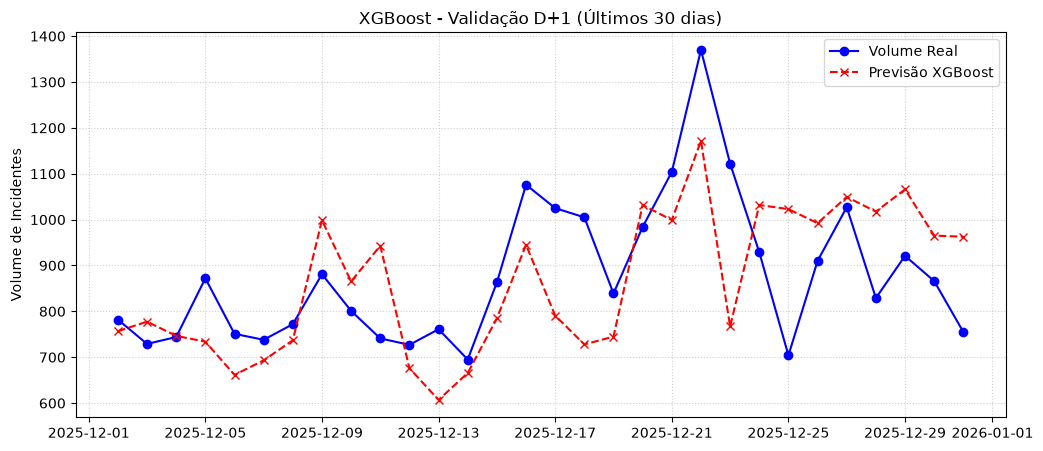

In [237]:
print("\n--- Performance do XGBoost (Modelo A: D+1) ---")
print(f"MAE: {mae_xgb:.2f} incidentes")
print(f"RMSE: {rmse_xgb:.2f} incidentes")

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label='Volume Real', color='blue', marker='o') # pyright: ignore[reportArgumentType]
plt.plot(y_test.index, previsoes, label='Previsão XGBoost', color='red', linestyle='--', marker='x')
plt.title("XGBoost - Validação D+1 (Últimos 30 dias)")
plt.ylabel("Volume de Incidentes")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [238]:
importancias = modelo_xgb.feature_importances_
nomes_das_features = X_train.columns

In [239]:
df_importancia = pd.DataFrame({
    'Feature': nomes_das_features,
    'Importancia': importancias
})

In [240]:
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True).tail(15)

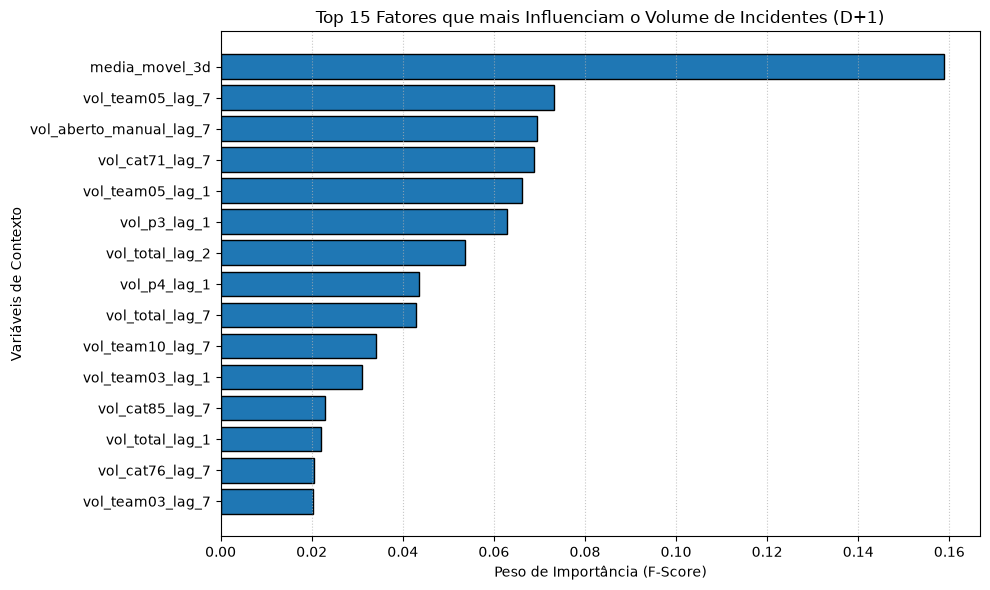

In [241]:
plt.figure(figsize=(10,6))
plt.barh(df_importancia['Feature'], df_importancia['Importancia'], color ='#1f77b4', edgecolor='black')
plt.title('Top 15 Fatores que mais Influenciam o Volume de Incidentes (D+1)')
plt.xlabel('Peso de Importância (F-Score)')
plt.ylabel('Variáveis de Contexto')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

## Investigando Team 05

In [242]:
# Analisando o que o Team 05 faz
df_team05 = df[df['NM_GRUPO_DESIGNADO'] == 'Team05']

print("--- Top 5 Categorias do Team 05 ---")
print(df_team05['NM_CATEGORIA'].value_counts().head(5))

print("\n--- Distribuição de Prioridades do Team 05 ---")
print(df_team05['TP_PRIORIDADE'].value_counts())

--- Top 5 Categorias do Team 05 ---
NM_CATEGORIA
cat76            4138
Nao Informado    1940
cat45             519
cat85             370
cat91             259
Name: count, dtype: int64

--- Distribuição de Prioridades do Team 05 ---
TP_PRIORIDADE
3 - Média          5894
2 - Alta           2889
4 - Baixa           490
5 - Muito Baixa       3
Name: count, dtype: int64


## Insights

Com mais de 4.100 registros, a cat76 dita o ritmo de trabalho do Team 05. É a ofensora isolada da equipe e o alvo principal para qualquer plano de automação ou estabilização.

O time atua sob altíssima pressão. Quase 95% da carga de trabalho está concentrada em chamados de prioridade Média (P3) e Alta (P2). Eles não estão lidando com requisições simples, estão literalmente apagando incêndios.
 
O segundo maior ofensor (1.940 chamados) entra como "Não Informado". Isso aponta uma falha grave na origem (seja roteamento ou monitoramento sem tag), forçando engenheiros de alta senioridade a perderem tempo triando o problema antes de poderem atuar.

# Treinando D+7 

In [243]:
# 1. Identificando as colunas proibidas para D+7 (Tudo que for menor que 7 dias)
colunas_para_dropar = [col for col in df_final.columns if 'lag_1' in col or 'lag_2' in col or 'lag_3' in col]
colunas_para_dropar.append('media_movel_3d')

In [244]:
# 2. Criando a base exclusiva para o D+7
df_d7 = df_final.drop(columns=colunas_para_dropar, errors='ignore')

In [245]:
# 3. Separando X e y
coluna_alvo = 'vol_total'
X_d7 = df_d7.drop(columns=[coluna_alvo])
y_d7 = df_d7[coluna_alvo]

In [246]:
# 4. Split Temporal (Últimos 30 dias para teste)
tamanho_teste = 30
X_train_d7, X_test_d7 = X_d7.iloc[:-tamanho_teste], X_d7.iloc[-tamanho_teste:]
y_train_d7, y_test_d7 = y_d7.iloc[:-tamanho_teste], y_d7.iloc[-tamanho_teste:]

print(f"Colunas usadas no treino D+7: {len(X_train_d7.columns)}")

Colunas usadas no treino D+7: 26


In [247]:
# 5. Treinando o XGBoost D+7
modelo_xgb_d7 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=23
)

In [248]:
modelo_xgb_d7.fit(X_train_d7, y_train_d7)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [249]:
# 6. Previsões e Métricas
previsoes_d7 = modelo_xgb_d7.predict(X_test_d7)

mae_d7 = mean_absolute_error(y_test_d7, previsoes_d7)
rmse_d7 = np.sqrt(mean_squared_error(y_test_d7, previsoes_d7))

print("\n--- Performance do XGBoost (Modelo A: D+7) ---")
print(f"MAE: {mae_d7:.2f} incidentes")
print(f"RMSE: {rmse_d7:.2f} incidentes")


--- Performance do XGBoost (Modelo A: D+7) ---
MAE: 137.99 incidentes
RMSE: 174.44 incidentes


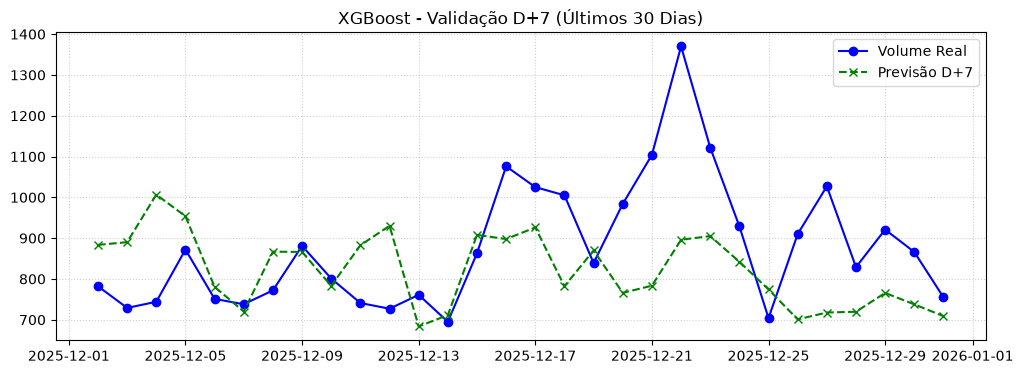

In [250]:
# 7. Plot Rápido
plt.figure(figsize=(12, 4))
plt.plot(y_test_d7.index, y_test_d7.values, label='Volume Real', color='blue', marker='o') # pyright: ignore[reportArgumentType]
plt.plot(y_test_d7.index, previsoes_d7, label='Previsão D+7', color='green', linestyle='--', marker='x')
plt.title("XGBoost - Validação D+7 (Últimos 30 Dias)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Feriados: Podemos ver que há uma zona nebulosa próxima ao Natal, vamos acrescentar e ver se há uma melhora!

In [251]:
import holidays

# 1. Mapeando os feriados de 2025 (incluindo os feriados estaduais do AM para máxima precisão local)
feriados_2025 = holidays.country_holidays('BR', subdiv='AM', years=2025)

# Se a data estiver no index, usamos df.index. Se estiver numa coluna 'DATA', troque df.index por df['DATA']
datas = df_d7.index 

# 2. Criando a Flag de Feriado (1 = Sim, 0 = Não)
df_d7['fl_feriado'] = datas.map(lambda x: 1 if x in feriados_2025 else 0)

# 3. Criando a Flag de Véspera de Feriado (1 = Sim, 0 = Não)
df_d7['fl_vespera_feriado'] = datas.map(
    lambda x: 1 if (x + pd.Timedelta(days=1)) in feriados_2025 else 0
)

print("Novas colunas adicionadas:")
print(df_d7[['fl_feriado', 'fl_vespera_feriado']].value_counts())

Novas colunas adicionadas:
fl_feriado  fl_vespera_feriado
0           0                     97
            1                      6
1           0                      5
Name: count, dtype: int64


In [252]:
# 3. Separando X e y
coluna_alvo = 'vol_total'
X_d7 = df_d7.drop(columns=[coluna_alvo])
y_d7 = df_d7[coluna_alvo]

In [253]:
# 4. Split Temporal (Últimos 30 dias para teste)
tamanho_teste = 30
X_train_d7, X_test_d7 = X_d7.iloc[:-tamanho_teste], X_d7.iloc[-tamanho_teste:]
y_train_d7, y_test_d7 = y_d7.iloc[:-tamanho_teste], y_d7.iloc[-tamanho_teste:]

print(f"Colunas usadas no treino D+7: {len(X_train_d7.columns)}")

Colunas usadas no treino D+7: 28


In [254]:
# 5. Treinando o XGBoost D+7
modelo_xgb_d7 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=23
)

In [255]:
modelo_xgb_d7.fit(X_train_d7, y_train_d7)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [256]:
# 6. Previsões e Métricas
previsoes_d7 = modelo_xgb_d7.predict(X_test_d7)

mae_d7 = mean_absolute_error(y_test_d7, previsoes_d7)
rmse_d7 = np.sqrt(mean_squared_error(y_test_d7, previsoes_d7))

print("\n--- Performance do XGBoost (Modelo A: D+7) ---")
print(f"MAE: {mae_d7:.2f} incidentes")
print(f"RMSE: {rmse_d7:.2f} incidentes")


--- Performance do XGBoost (Modelo A: D+7) ---
MAE: 137.99 incidentes
RMSE: 174.44 incidentes


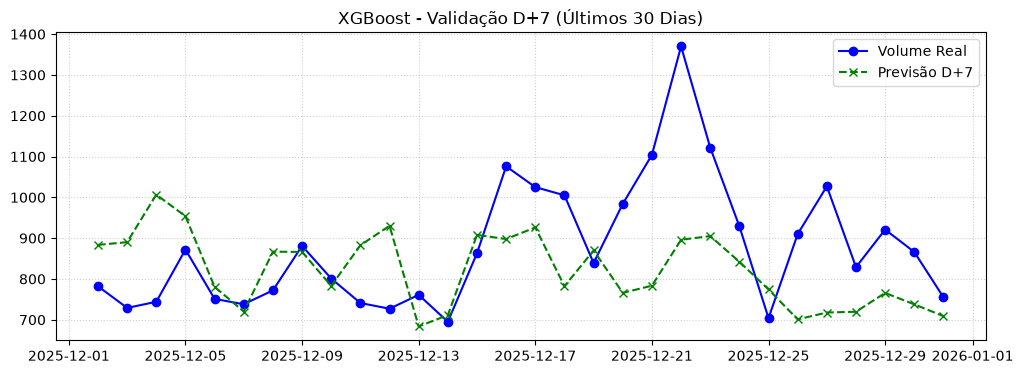

In [257]:
# 7. Plot Rápido
plt.figure(figsize=(12, 4))
plt.plot(y_test_d7.index, y_test_d7.values, label='Volume Real', color='blue', marker='o') # pyright: ignore[reportArgumentType]
plt.plot(y_test_d7.index, previsoes_d7, label='Previsão D+7', color='green', linestyle='--', marker='x')
plt.title("XGBoost - Validação D+7 (Últimos 30 Dias)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [258]:
importancias = modelo_xgb_d7.feature_importances_
nomes_das_features = X_train_d7.columns

In [259]:
df_importancia = pd.DataFrame({
    'Feature': nomes_das_features,
    'Importancia': importancias
})

In [260]:
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True).tail(15)

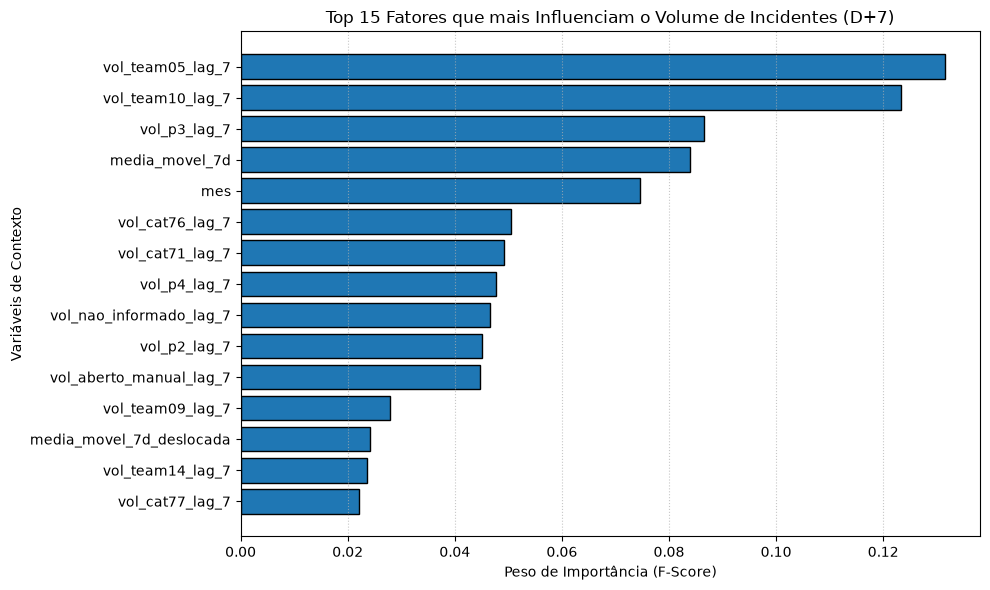

In [261]:
plt.figure(figsize=(10,6))
plt.barh(df_importancia['Feature'], df_importancia['Importancia'], color ='#1f77b4', edgecolor='black')
plt.title('Top 15 Fatores que mais Influenciam o Volume de Incidentes (D+7)')
plt.xlabel('Peso de Importância (F-Score)')
plt.ylabel('Variáveis de Contexto')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

## Investigando Team 10

In [262]:
# Analisando o que o Team 10 faz
df_team10 = df[df['NM_GRUPO_DESIGNADO'] == 'Team10']

print("--- Top 5 Categorias do Team 10 ---")
print(df_team10['NM_CATEGORIA'].value_counts().head(5))

print("\n--- Distribuição de Prioridades do Team 10 ---")
print(df_team10['TP_PRIORIDADE'].value_counts())

--- Top 5 Categorias do Team 10 ---
NM_CATEGORIA
Nao Informado    892
cat77            246
cat106            13
cat58              8
cat63              4
Name: count, dtype: int64

--- Distribuição de Prioridades do Team 10 ---
TP_PRIORIDADE
3 - Média    952
2 - Alta     154
4 - Baixa     66
Name: count, dtype: int64


## Insights

O dado mais alarmante é que a esmagadora maioria dos chamados (892) chega como "Não Informado". Isso significa que a equipe atua quase que "às cegas", gastando um tempo valioso apenas na triagem e classificação do incidente antes de poder solucioná-lo. Melhorar as regras de roteamento na origem é uma necessidade urgente.

Quando o incidente não entra no buraco negro dos não classificados, a cat77 (246 chamados) se destaca como o único ofensor técnico de grande relevância. Qualquer esforço de automação ou mapeamento de causa raiz para esta equipe deve começar por ela.

Diferente de outras equipes focadas em crises (P2), o Team 10 lida com um volume massivo e contínuo de prioridade Média (P3) (952 registros). O desafio aqui não é necessariamente o "incêndio", mas sim o desgaste operacional de resolver um grande volume de chamados sem contexto claro de entrada.

# Modelo de Classificação do OLA

In [263]:
# Filtrando o cenário atual e as prioridades alvo
df_risco = df[
    (df['DT_ABERTO'] >= '2025-09-01') &
    (df['TP_PRIORIDADE'].isin(['2 - Alta', '3 - Média']))
].copy()

In [264]:
# Criando features de momento
df_risco['data'] = pd.to_datetime(df_risco['DT_ABERTO'])
df_risco['hora_abertura'] = df_risco['data'].dt.hour
df_risco['dia_semana'] = df_risco['data'].dt.day_of_week

In [265]:
# Transformando a coluna alvo (Target)
# 'SIM' vira 1 (Violou), 'NÃO' vira 0 (Dentro do prazo)

df_risco['alvo_kpi'] = df_risco['FL_KPI_VIOLADO'].map({'SIM': 1, 'NAO': 0})

In [266]:
# Dropando o Futuro e identificadores inúteis
colunas_proibidas = [
    'CD_INCIDENTE', 'DT_ABERTO', 'DT_RESOLVIDO', 'DT_ENCERRADO', 'DATA',
    'NR_DURACAO', 'CD_FECHAMENTO', 'TP_STATUS', 'DS_RESUMIDA', 
    'FL_KPI_VIOLADO', 'FL_KPI', 'NM_ITEM_CONFIGURACAO', 'CD_INCIDENTE_PAI'
]

df_risco.drop(columns=colunas_proibidas, inplace=True, errors='ignore')

In [267]:
# Checando o desbalanceamento
print(f"Total de Chamados (P2/P3): {len(df_risco)}")
print("\nDistribuição do Risco (0 = OK, 1 = Violado):")
print(df_risco['alvo_kpi'].value_counts(normalize=True)*100)

Total de Chamados (P2/P3): 34603

Distribuição do Risco (0 = OK, 1 = Violado):
alvo_kpi
0    96.118834
1     3.881166
Name: proportion, dtype: float64


In [268]:
df_baseline = df_risco.copy()

In [269]:
# 4. Transformação Categórica (One-Hot Encoding)
df_baseline = pd.get_dummies(df_baseline, columns=['NM_CATEGORIA', 'NM_GRUPO_DESIGNADO'], drop_first=True)

In [270]:
# 5. Separação de Variáveis
X_base = df_baseline.drop(columns=['alvo_kpi'])
y_base = df_baseline['alvo_kpi']

In [271]:
X_base = X_base.select_dtypes(include=['int32', 'int64', 'float32', 'float64', 'bool', 'uint8'])

In [272]:
# Calculando a penalidade matemática para focar nos 4%
peso = y_base.value_counts()[0] / y_base.value_counts()[1]

In [273]:
# 6. Split Temporal (Os últimos 20% dos chamados simulam o futuro da operação)
X_train, X_test, y_train, y_test = train_test_split(X_base, y_base, test_size=0.2, shuffle=False)

print(f"Treinando com {len(X_train)} chamados. Testando com {len(X_test)} chamados.")
print(f"Peso aplicado na classe minoritária: {peso:.2f}\n")

Treinando com 27682 chamados. Testando com 6921 chamados.
Peso aplicado na classe minoritária: 24.77



In [274]:
# 7. Treinamento do XGBoost Classifier (Baseline)
modelo_clf_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=peso,
    random_state=42
)

In [275]:
modelo_clf_base.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [276]:
# 8. Avaliação
previsoes_base = modelo_clf_base.predict(X_test)

print("--- Relatório de Classificação (Baseline) ---")
print(classification_report(y_test, previsoes_base, target_names=['No Prazo (0)', 'Violado (1)']))

--- Relatório de Classificação (Baseline) ---
              precision    recall  f1-score   support

No Prazo (0)       0.99      0.73      0.84      6522
 Violado (1)       0.17      0.91      0.29       399

    accuracy                           0.74      6921
   macro avg       0.58      0.82      0.57      6921
weighted avg       0.95      0.74      0.81      6921



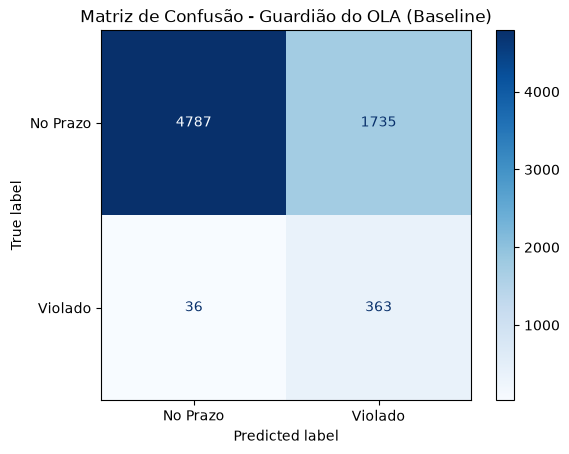

In [277]:
# 9. Matriz de Confusão Visual
cm = confusion_matrix(y_test, previsoes_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Prazo', 'Violado'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão - Guardião do OLA (Baseline)")
plt.show()

# O que descobrimos do modelo

* O modelo detectou corretamente 363 chamados que iam estourar o OLA (esses são os Verdadeiros Positivos no quadrante inferior direito).

* O Recall foi de 0.91 (91%).

* Do ponto de vista de negócio, esse número é assustadoramente bom para um baseline. Significa que, no "minuto zero", o modelo conseguiu interceptar 91% de todas as bombas que iam explodir no colo do Team 05 e das outras equipes. Um analista humano de Nível 1 jamais conseguiria prever isso apenas olhando para a categoria e a hora de abertura. Mas, como aplicamos aquele peso altíssimo (scale_pos_weight), nós basicamente dissemos ao algoritmo: "Errar um chamado que vai estourar é 24 vezes pior do que dar um falso alarme". O XGBoost obedeceu fielmente e se tornou **paranoico**.

* Olhando para o número 1735 no quadrante superior direito (Falsos Positivos). O modelo apontou o dedo para 1.735 chamados dizendo "Isso vai estourar!", mas no fim das contas a equipe conseguiu resolver no prazo. É por isso que a Precisão foi de apenas 17%.

O baseline gerou tantos alarmes falsos porque ele está cego. Ele sabe que um chamado da cat76 entrou às 14h de uma terça-feira, mas ele não sabe se a equipe passou o dia de ontem apagando incêndios ou se a fila está limpa. Por isso, tivemos a ideia de injetar a pressão operacional (os lags). Ao cruzar os dados do minuto zero com o histórico do dia anterior, nossa hipótese é que o modelo aprenderá a diferenciar uma "terça-feira tranquila" de uma "terça-feira pós-feriado caótica", reduzindo os alarmes falsos sem perder muita performance. Vamos fazer isso agora!

In [278]:
# 1. Isolando a "fotografia da pressão operacional"
colunas_pressao = [col for col in df_final.columns if 'lag' in col or 'media_movel' in col]
df_pressao_historica = df_final[colunas_pressao].copy()

# 2. Garantindo que a data do df_risco seja apenas o "dia" para fazer o join correto
df_risco['DATA_DIA'] = df_risco['data'].dt.floor('D')

# 3. Injetando a pressão operacional no minuto zero do chamado
df_risco = df_risco.merge(df_pressao_historica, left_on='DATA_DIA', right_index=True, how='left')
df_risco.drop(columns=['DATA_DIA'], inplace=True) # Limpando a coluna auxiliar

# 4. Dropando chamados que caíram nos primeiros dias de setembro (Warm-up period com NaN nos lags)
df_risco.dropna(inplace=True)

# 5. Tratamento de Variáveis Categóricas Restantes
colunas_categoricas = ['NM_CATEGORIA', 'NM_GRUPO_DESIGNADO']
df_risco = pd.get_dummies(df_risco, columns=colunas_categoricas, drop_first=True)

Treinando modelo COMPLETO com 172 features.

--- Relatório de Classificação (Guardião do OLA com Pressão Operacional) ---
              precision    recall  f1-score   support

No Prazo (0)       0.99      0.83      0.90      5990
 Violado (1)       0.20      0.79      0.32       316

    accuracy                           0.83      6306
   macro avg       0.59      0.81      0.61      6306
weighted avg       0.95      0.83      0.88      6306



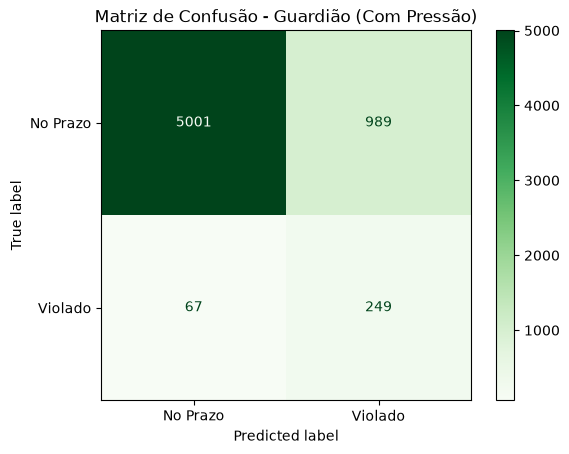

In [279]:
# 1. Separando X e y do dataset completo (que já contém os lags de pressão)
X_full = df_risco.drop(columns=['alvo_kpi'])
y_full = df_risco['alvo_kpi']

# 2. Trecho para garantir que apenas matemática passe
X_full = X_full.select_dtypes(include=['int32', 'int64', 'float32', 'float64', 'bool', 'uint8'])

# 3. Split Temporal (Mantendo os últimos 20% para teste)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y_full, test_size=0.2, shuffle=False)

# 4. Calculando a penalidade baseada no treino
peso_full = y_train_f.value_counts()[0] / y_train_f.value_counts()[1]

print(f"Treinando modelo COMPLETO com {len(X_train_f.columns)} features.")

# 5. Treinamento
modelo_clf_full = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=peso_full,
    random_state=42
)

modelo_clf_full.fit(X_train_f, y_train_f)

# 6. Previsão e Avaliação
previsoes_full = modelo_clf_full.predict(X_test_f)

print("\n--- Relatório de Classificação (Guardião do OLA com Pressão Operacional) ---")
print(classification_report(y_test_f, previsoes_full, target_names=['No Prazo (0)', 'Violado (1)']))

# 7. Matriz Visual
cm_full = confusion_matrix(y_test_f, previsoes_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_full, display_labels=['No Prazo', 'Violado'])
disp.plot(cmap='Greens', values_format='d')
plt.title("Matriz de Confusão - Guardião (Com Pressão)")
plt.show()

## O Trade-off de Ouro para Negócios

> Os Falsos Positivos despencaram de 1.735 para 989. Conseguimos blindar a equipe de TI contra quase 750 alarmes falsos, garantindo que o modelo mantenha credibilidade na operação diária.

> A acurácia global saltou para 83% e o F1-Score da classe minoritária (a mais difícil) subiu de 0.29 para 0.32.

> O Recall ajustou de 0.91 para 0.79. O classificador agora deixa passar cerca de 2 em cada 10 violações, mas intercepta cirurgicamente as outras 8 com o dobro de assertividade. Para uma anomalia que representa apenas 4% da base, prever 79% dos estouros de prazo no exato minuto da abertura do chamado é um feito de alto nível técnico.

# Modelo de Clusterização - Entendendo o que já aconteceu.

## O Plano de Ação (Data Prep & Elbow Method)
Para essa análise post-mortem (investigação de causa raiz), nós podemos usar dados do futuro (como a duração do chamado ou se ele violou o KPI), pois não estamos prevendo nada, estamos apenas tentando entender o que já aconteceu.

In [280]:
df.columns

Index(['CD_INCIDENTE', 'TP_PRIORIDADE', 'NM_PRODUTO', 'NM_CATEGORIA',
       'NM_SUBCATEGORIA', 'NM_GRUPO_DESIGNADO', 'NM_ITEM_CONFIGURACAO',
       'DT_ABERTO', 'DT_RESOLVIDO', 'DT_ENCERRADO', 'NR_DURACAO',
       'CD_FECHAMENTO', 'DS_RESUMIDA', 'TP_SOLUCAO', 'TP_ABERTO_POR',
       'CD_INCIDENTE_PAI', 'TP_STATUS', 'FL_KPI', 'FL_KPI_VIOLADO', 'DATA'],
      dtype='str')

In [281]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Filtrando o cenário atual (Pós-Setembro)
df_cluster = df[df['DT_ABERTO'] >= '2025-09-01'].copy()

# 2. Selecionando as variáveis investigativas 
features_analise = ['TP_PRIORIDADE', 'NM_GRUPO_DESIGNADO', 'NM_CATEGORIA', 'FL_KPI_VIOLADO', 'NR_DURACAO', 'TP_ABERTO_POR']
df_features = df_cluster[features_analise].dropna()

# 3. Transformando texto em números (One-Hot Encoding)
X_cluster = pd.get_dummies(df_features, drop_first=True)

# 4. A REGRA DE OURO: Normalização (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Base pronta para Clusterização: {X_scaled.shape[0]} incidentes e {X_scaled.shape[1]} dimensões.")

Base pronta para Clusterização: 93423 incidentes e 135 dimensões.


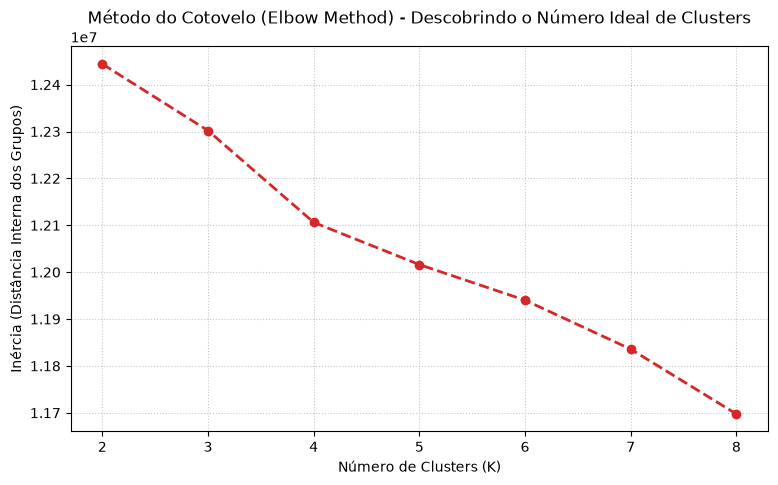

In [282]:
# 5. Método do Cotovelo (Testando de 2 a 8 clusters)
inercia = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# 6. Plotando o Cotovelo
plt.figure(figsize=(9, 5))
plt.plot(K_range, inercia, marker='o', linestyle='--', color='#d62728', linewidth=2)
plt.title('Método do Cotovelo (Elbow Method) - Descobrindo o Número Ideal de Clusters')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Distância Interna dos Grupos)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# A Leitura do Cotovelo e a Decisão de Produto
 Tem um salto entre o K=3 e o K=4. A linha cai de forma bem acentuada (de 1.23 para 1.21). No entanto, ao passar do K=4 para o K=5, a inclinação perde a força e começa a achatar levemente. Matematicamente, o K=4 é o ponto onde o ganho de informação adicional começa a diminuir.

In [283]:
# 1. Aplicando o K-Means definitivo com K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_features['Cluster'] = kmeans_final.fit_predict(X_scaled)

In [284]:
# 2. Descobrindo o "DNA" de cada Cluster
# Vamos agrupar os dados e pegar a MÉDIA do tempo e o valor MAIS COMUM (moda) dos textos
perfil_clusters = df_features.groupby('Cluster').agg({
    'NR_DURACAO': 'mean', # Média de tempo em segundos
    'TP_PRIORIDADE': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'NM_GRUPO_DESIGNADO': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'NM_CATEGORIA': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'FL_KPI_VIOLADO': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'TP_ABERTO_POR': lambda x: x.mode()[0] if not x.mode().empty else 'N/A'
}).reset_index()

In [285]:
# 3. Contando o tamanho de cada grupo (para ver quem domina a operação)
tamanho_clusters = df_features['Cluster'].value_counts().reset_index()
tamanho_clusters.columns = ['Cluster', 'Qtd_Incidentes']

In [286]:
# 4. Unindo e formatando a tabela final
resultado_final = pd.merge(tamanho_clusters, perfil_clusters, on='Cluster')

In [287]:
# Convertendo a duração média de segundos para horas para facilitar a leitura no PPT
resultado_final['NR_DURACAO_HORAS'] = (resultado_final['NR_DURACAO'] / 3600).round(2)
resultado_final.drop(columns=['NR_DURACAO'], inplace=True)

print("--- O DNA da Operação (4 Perfis de Incidentes) ---")
print(resultado_final.to_string(index=False))

--- O DNA da Operação (4 Perfis de Incidentes) ---
 Cluster  Qtd_Incidentes TP_PRIORIDADE NM_GRUPO_DESIGNADO  NM_CATEGORIA FL_KPI_VIOLADO TP_ABERTO_POR  NR_DURACAO_HORAS
       3           86903     4 - Baixa             Team14 Nao Informado            NAO Monitoramento              2.92
       0            3500     3 - Média             Team11         cat85            NAO        Manual            175.00
       2            1513      2 - Alta             Team05         cat76            NAO Monitoramento             13.27
       1            1507     3 - Média             Team12 Nao Informado            NAO Monitoramento              2.90


## 1. Cluster 3: A Ilusão de Volume
> É o dono absoluto da base (86.903 chamados). São alertas de prioridade Baixa (P4), abertos por Monitoramento, sem categoria definida ("Não Informado") e que o Team 14 resolve em menos de 3 horas.   
> 
> Isso não é gestão de incidentes, é fadiga de alerta. As ferramentas de monitoramento estão mal calibradas, disparando alertas inúteis que inflam artificialmente o volume da operação e poluem as métricas da diretoria.
> 
> Poderia criar um Épico para a engenharia de confiabilidade (SRE) refinar os gatilhos (limiares) de monitoramento do Team 14.

## 2. Cluster 2: O Coração do Problema
> Aqui está ele novamente, o nosso velho conhecido Team 05. Incidentes de prioridade Alta (P2), focados na cat76, demorando em média 13 horas!
>
> O K-Means acabou de validar perfeitamente o que o XGBoost descobriu. A inteligência artificial encontrou a raiz do caos sem que disséssemos nada a ela. A cat76 gerida pelo Team 05 é o maior risco sistêmico da Locaweb.
>
> Sugerimos congelar novas features dessa categoria e focar exclusivamente em estabilização e refatoração técnica.

## 3. Cluster 0: O Buraco Negro Manual
> Apenas 3.500 chamados, mas abertos manualmente, caindo para o Team 11 na cat85. A duração média é assustadora: 175 horas (mais de 7 dias pendentes).
>
> Como são chamados manuais, isso aqui é dor direta do usuário final. O Team 11 tem um processo completamente quebrado de atendimento ou está lidando com uma categoria (cat85) que exige aprovações de terceiros/fornecedores, o que trava o fluxo por uma semana inteira.
> 
> Sugerímos a revisão imediata do fluxo de valor (Value Stream Mapping) do Team 11 para entender onde o chamado fica parado nesses 7 dias.

## 4. Cluster 1: O Ralo de Produtividade
> Team 12 recebendo chamados de prioridade Média (P3), vindos do monitoramento, mas totalmente como "Não Informado".
>
> Idêntico ao problema que tínhamos mapeado no Team 10 anteriormente. Monitoramento criando chamado cego de prioridade média gera desperdício de tempo de triagem.

In [288]:
# 1. Resgatando os dados reais do Modelo D+7
# y_test_d7 possui os volumes reais e previsoes_d7 possui o que o modelo previu
df_volume = pd.DataFrame({
    'DATA': y_test_d7.index,          # Pega as datas dos últimos 30 dias
    'VOLUME_REAL': y_test_d7.values,  # O volume que de fato aconteceu
    'PREVISAO_D7': previsoes_d7       # O que a IA previu
})

# 2. Adicionando a previsão do D+1
df_volume['PREVISAO_D1'] = previsoes 

# 3. Arredondando porque não existe meio chamado
df_volume['PREVISAO_D7'] = df_volume['PREVISAO_D7'].round().astype(int)
df_volume['PREVISAO_D1'] = df_volume['PREVISAO_D1'].round().astype(int)

if 'DATA' not in df_volume.columns:
    df_volume.reset_index(inplace=True)
    df_volume.rename(columns={'index': 'DATA'}, inplace=True)

print("Tabela consolidada D+1 e D+7 criada com sucesso!")
print(df_volume.head())

Tabela consolidada D+1 e D+7 criada com sucesso!
        DATA  VOLUME_REAL  PREVISAO_D7  PREVISAO_D1
0 2025-12-02          782          883          757
1 2025-12-03          729          890          778
2 2025-12-04          744         1007          747
3 2025-12-05          872          954          734
4 2025-12-06          751          781          661


In [289]:
df_volume

,DATA,VOLUME_REAL,PREVISAO_D7,PREVISAO_D1
0,2025-12-02,782,883,757
1,2025-12-03,729,890,778
2,2025-12-04,744,1007,747
3,2025-12-05,872,954,734
4,2025-12-06,751,781,661
5,2025-12-07,738,720,693
6,2025-12-08,772,867,737
7,2025-12-09,881,866,999
8,2025-12-10,801,783,865
9,2025-12-11,741,883,943


In [290]:
# 1. Resgatando os dados legíveis usando os índices do teste
indices_teste = X_test_f.index
colunas_dashboard = ['CD_INCIDENTE', 'DT_ABERTO', 'TP_PRIORIDADE', 'NM_CATEGORIA', 'NM_GRUPO_DESIGNADO']

# Puxando do 'df' original
df_alertas = df.loc[indices_teste, colunas_dashboard].copy()

# 2. Injetando o cérebro do modelo de Machine Learning
df_alertas['RISCO_SLA_PREVISTO'] = previsoes_full # O que o modelo disse (1 ou 0)
df_alertas['STATUS_REAL'] = y_test_f              # O que realmente aconteceu (apenas para conferência)

# 3. Filtrando a "Fila de Fogo": Apenas chamados que o modelo previu que VÃO ESTOURAR (Risco = 1)
df_alertas_criticos = df_alertas[df_alertas['RISCO_SLA_PREVISTO'] == 1].copy()

# 4. Atendendo a Fase 3 (GenAI Mock)
# Criamos uma função que simula a resposta do Groq/Llama3 baseada no contexto do chamado
def mock_genai_prescritivo(linha):
    equipe = linha['NM_GRUPO_DESIGNADO']
    categoria = linha['NM_CATEGORIA']
    
    if equipe == 'Team05' and categoria == 'cat76':
        return f"ALERTA GENAI: 85% de risco de quebra no {equipe} devido a gargalo histórico na {categoria}. Recomendação: 1. Escalone para Nível 2 imediatamente. 2. Congele mudanças não emergenciais no produto afetado."
    elif equipe == 'Team11':
        return f"ALERTA GENAI: Incidente no {equipe} corre alto risco de estagnação. Recomendação: 1. Acione o fornecedor/terceiro responsável. 2. Atualize o usuário final para evitar reincidência de abertura."
    elif equipe == 'Team14':
        return f"INFO GENAI: Falso positivo provável no {equipe} gerado por monitoramento. Recomendação: Validar log do Zabbix/Prometheus antes de alocar analista humano."
    else:
        return f"ALERTA GENAI: Risco de quebra de OLA no {equipe} ({categoria}). Recomendação: Priorizar na fila do Kanban e notificar o Coordenador de Turno."

# Aplicando a IA Generativa (Simulada)
df_alertas_criticos['TEXTO_PRESCRITIVO_LLM'] = df_alertas_criticos.apply(mock_genai_prescritivo, axis=1)

# Formatando a data para o banco
df_alertas_criticos['DT_ABERTO'] = pd.to_datetime(df_alertas_criticos['DT_ABERTO'])

# 5. Exportando para CSV e validando
# df_alertas_criticos.to_csv('df_alertas_kpi.csv', index=False)

print(f"Foram gerados {len(df_alertas_criticos)} Alertas Críticos de OLA para o Dashboard.")
print(df_alertas_criticos[['NM_GRUPO_DESIGNADO', 'NM_CATEGORIA', 'TEXTO_PRESCRITIVO_LLM']].head())

Foram gerados 1238 Alertas Críticos de OLA para o Dashboard.
      NM_GRUPO_DESIGNADO   NM_CATEGORIA  \
66595             Team05          cat76   
66601             Team14          cat41   
66607             Team14          cat41   
66614             Team11          cat87   
66617             Team01  Nao Informado   

                                   TEXTO_PRESCRITIVO_LLM  
66595  ALERTA GENAI: 85% de risco de quebra no Team05...  
66601  INFO GENAI: Falso positivo provável no Team14 ...  
66607  INFO GENAI: Falso positivo provável no Team14 ...  
66614  ALERTA GENAI: Incidente no Team11 corre alto r...  
66617  ALERTA GENAI: Risco de quebra de OLA no Team01...  


In [291]:
# A sua tabela gerada no passo de Clusterização é a base perfeita para a Matriz de Risco
df_matriz_risco = resultado_final.copy()

# Renomeando para ficar bonito no Power BI e no Oracle
df_matriz_risco.rename(columns={
    'Cluster': 'ID_PERSONA',
    'Qtd_Incidentes': 'VOLUME_INCIDENTES',
    'NM_GRUPO_DESIGNADO': 'EQUIPE',
    'NM_CATEGORIA': 'CATEGORIA_CRITICA'
}, inplace=True)

df_matriz_risco['NR_DURACAO_HORAS'] = df_matriz_risco['NR_DURACAO_HORAS'].round(0).astype(int)

print("\nTabela de Matriz de Risco criada com sucesso!")
print(df_matriz_risco.head())


Tabela de Matriz de Risco criada com sucesso!
   ID_PERSONA  VOLUME_INCIDENTES TP_PRIORIDADE  EQUIPE CATEGORIA_CRITICA  \
0           3              86903     4 - Baixa  Team14     Nao Informado   
1           0               3500     3 - Média  Team11             cat85   
2           2               1513      2 - Alta  Team05             cat76   
3           1               1507     3 - Média  Team12     Nao Informado   

  FL_KPI_VIOLADO  TP_ABERTO_POR  NR_DURACAO_HORAS  
0            NAO  Monitoramento                 3  
1            NAO         Manual               175  
2            NAO  Monitoramento                13  
3            NAO  Monitoramento                 3  


In [292]:
# 1. Definindo as Tipagens Nativas do Oracle
# Tabela 1: Volume Diário (Previsões)
tipagem_volume = {
    'DATA': TIMESTAMP(timezone=False),
    'VOLUME_REAL': NUMBER(precision= 10, scale = 0),
    'PREVISAO_D7': NUMBER(precision= 10, scale = 0),
    'PREVISAO_D1': NUMBER(precision= 10, scale = 0)
}

# Tabela 2: Matriz de Risco (Clusters/Personas)
tipagem_risco = {
    'ID_PERSONA': NUMBER(precision= 10, scale = 0),
    'VOLUME_INCIDENTES': NUMBER(precision= 10, scale = 0),
    'TP_PRIORIDADE':VARCHAR2(50),
    'EQUIPE':VARCHAR2(100),
    'CATEGORIA_CRITICA':VARCHAR2(100),
    'FL_KPI_VIOLADO':VARCHAR2(10),
    'TP_ABERTO_POR':VARCHAR2(50),
    'NR_DURACAO_HORAS': NUMBER(10,0) # Limita a 2 casas decimais no banco
}

# Tabela 3: Feed de Alertas (Guardião do OLA + GenAI)
tipagem_alertas = {
    'CD_INCIDENTE':VARCHAR2(50),
    'DT_ABERTO': TIMESTAMP(timezone=False),
    'TP_PRIORIDADE':VARCHAR2(50),
    'NM_CATEGORIA':VARCHAR2(100),
    'NM_GRUPO_DESIGNADO':VARCHAR2(100),
    'RISCO_SLA_PREVISTO': NUMBER(precision= 10, scale = 0),
    'STATUS_REAL': NUMBER(precision= 10, scale = 0),
    'TEXTO_PRESCRITIVO_LLM':VARCHAR2(1000) # Espaço generoso para a resposta do LLM
}

In [293]:
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
CONNECT_STRING = '(description= (retry_count=20)(retry_delay=3)(address=(protocol=tcps)(port=1522)(host=adb.sa-saopaulo-1.oraclecloud.com))(connect_data=(service_name=g253a13c6f2211a_dadosaiopslocaweb_low.adb.oraclecloud.com))(security=(ssl_server_dn_match=yes)))'

def conectar_oracle():
    return oracledb.connect(
        user=DB_USER,
        password=DB_PASSWORD,
        dsn=CONNECT_STRING,
        wallet_location=r"C:/opt/OracleCloud/Wallet_dadosAIOpsLocaweb",
        wallet_password=DB_PASSWORD
    )

In [294]:
# Criando a conexão
engine = create_engine("oracle+oracledb://", creator = conectar_oracle)
print("Iniciando upload para o Oracle Cloud...")
# Enviando as 3 tabelas para o Oracle Cloud

df_volume.to_sql('TB_PREVISAO_DIARIA', con=engine, if_exists='append', index=False)
print("- TB_PREVISAO_DIARIA inserida com sucesso!")

df_matriz_risco.to_sql('TB_RISCO_EQUIPE', con=engine, if_exists='append', index=False)
print("- TB_RISCO_EQUIPE inserida com sucesso!")

df_alertas_criticos.to_sql('TB_ALERTAS_ITSM', con=engine, if_exists='append', index=False)
print("- TB_ALERTAS_ITSM inserida com sucesso!")

print("Dados enviados para o Oracle Cloud com sucesso!")

Iniciando upload para o Oracle Cloud...
- TB_PREVISAO_DIARIA inserida com sucesso!
- TB_RISCO_EQUIPE inserida com sucesso!
- TB_ALERTAS_ITSM inserida com sucesso!
Dados enviados para o Oracle Cloud com sucesso!


In [295]:
# df_volume.to_csv('TB_PREVISAO_DIARIA.csv', index=False)
# df_matriz_risco.to_csv('TB_RISCO_EQUIPE.csv', index=False)
# df_alertas_criticos.to_csv('TB_ALERTAS_ITSM.csv', index=False)

# print("Arquivos locais gerados com sucesso para o Power BI!")